# Project Milestone One: Gathering your Team, Understanding the Problem,  Exploring the Data

#### Due: Midnight on March 29th (with 2-hour grace period)  

#### There will be no late period on this homework, as we need to start manual grading immediately! 



### What We Will Do in This Milestone Assignment

1. You will convene your team and fill out the Team Contract (in the Homework Repo), to be submitted to Gradescope.
2. You must select a team leader for the purpose of submitting this notebook, after the team collaborates to complete the assignment. This <a href=https://guides.gradescope.com/hc/en-us/articles/21863861823373-Adding-Group-Members-to-a-Submission>link</a> describes how to add group members to your leader's submission. 
3. At the conclusion of your work on this Milestone, you will complete an Individual Evaluation of your team's work (in the Homework Repo) and upload it *individually* to Gradescope.
4. We will follow a simplified version of the **Machine Learning Project Checklist** in Appendix A in our textbook *Hands-On Machine Learning* (pp.779):  

>Part 1:	Frame the problem and look at the big picture  
Part 2: Download and perform preliminary exploration of the data  
Part 3: Clean the Data: Drop, Impute, and Encode   
Part 4: Explore Feature Relationships  
Part 5: Investigate Feature Engineering options to better expose the underlying data patterns  

### The Dataset

All teams will use the same dataset. It is a smaller version of the Zillow housing dataset that was used in the
Zillow Million Dollar Prize which ran on Kaggle in 2017 (sorry, the contest is closed, so you can't win any money
with this project!).  We will try to predict the assessed tax value (`'taxvaluedollarcnt'`) of the property from a large collection
of descriptors. Some features are closely related and some are obviously useless.  There are potential outliers and also quite a few missing values. 

This is a good example of a dataset which has not been predigested for you on Kaggle, and should give you a good chance to
try all the various tools in your toolbox!


In [1]:
# =============================
# Useful Imports
# =============================

# Standard Libraries
import os
import time
import math
import io
import zipfile
import requests
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
import seaborn as sns

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker  # Optional: Format y-axis labels as dollars

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split, 
    cross_val_score, 
    GridSearchCV, 
    RandomizedSearchCV, 
    RepeatedKFold
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest
from sklearn.datasets import make_regression
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor

# Kaggle and Progress Tracking
from tqdm import tqdm

# =============================
# Global Variables
# =============================
random_state = 42

# =============================
# Utility Functions
# =============================

# Format y-axis labels as dollars with commas (optional)
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Convert seconds to HH:MM:SS format
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))



## Prelude: Download the Zillow Housing Dataset 

The code cell below will load the dataset for you.    

> **Notice that before downloading, this cell first checks whether the files already exist.** 

For a detailed description of the dataset features, please refer to  **Appendix 1** below. 

**Note:** Do **not** perform a train/test split for this milestone (unlike HOML suggests), since you need to do the split **after** any data preparation and feature engineering. You can wait until Milestone 2 to do the split. 

In [2]:

url = "https://www.cs.bu.edu/fac/snyder/cs505/Data/zillow_dataset.csv"

filename = os.path.basename(urlparse(url).path)

if not os.path.exists(filename):
    try:
        print("Downloading the file...")
        response = requests.get(url)
        response.raise_for_status()  # Raise an error for bad status codes
        with open(filename, "wb") as f:
            f.write(response.content)
        print("File downloaded successfully.")
    except requests.exceptions.RequestException as e:
        print(f"Error downloading the file: {e}")
else:
    print("File already exists. Skipping download.")

df = pd.read_csv(filename)

File already exists. Skipping download.


In [3]:
print(df.shape)
df.head()

(77613, 55)


,parcelid,airconditioningtypeid,architecturalstyletypeid,basementsqft,bathroomcnt,bedroomcnt,buildingclasstypeid,buildingqualitytypeid,calculatedbathnbr,decktypeid,...,yardbuildingsqft17,yardbuildingsqft26,yearbuilt,numberofstories,fireplaceflag,assessmentyear,taxdelinquencyflag,taxdelinquencyyear,censustractandblock,taxvaluedollarcnt
0,14297519,NaN,NaN,NaN,3.5,4.0,NaN,NaN,3.5,NaN,...,NaN,NaN,1998.0,NaN,NaN,2016.0,NaN,NaN,6.059063e+13,1023282.0
1,17052889,NaN,NaN,NaN,1.0,2.0,NaN,NaN,1.0,NaN,...,NaN,NaN,1967.0,1.0,NaN,2016.0,NaN,NaN,6.111001e+13,464000.0
2,14186244,NaN,NaN,NaN,2.0,3.0,NaN,NaN,2.0,NaN,...,NaN,NaN,1962.0,1.0,NaN,2016.0,NaN,NaN,6.059022e+13,564778.0
3,12177905,NaN,NaN,NaN,3.0,4.0,NaN,8.0,3.0,NaN,...,NaN,NaN,1970.0,NaN,NaN,2016.0,NaN,NaN,6.037300e+13,145143.0
4,10887214,1.0,NaN,NaN,3.0,3.0,NaN,8.0,3.0,NaN,...,NaN,NaN,1964.0,NaN,NaN,2016.0,NaN,NaN,6.037124e+13,119407.0


In [4]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values (top 20):")
print(df.isna().sum().sort_values(ascending=False).head(20))

Shape: (77613, 55)

Columns:
['parcelid', 'airconditioningtypeid', 'architecturalstyletypeid', 'basementsqft', 'bathroomcnt', 'bedroomcnt', 'buildingclasstypeid', 'buildingqualitytypeid', 'calculatedbathnbr', 'decktypeid', 'finishedfloor1squarefeet', 'calculatedfinishedsquarefeet', 'finishedsquarefeet12', 'finishedsquarefeet13', 'finishedsquarefeet15', 'finishedsquarefeet50', 'finishedsquarefeet6', 'fips', 'fireplacecnt', 'fullbathcnt', 'garagecarcnt', 'garagetotalsqft', 'hashottuborspa', 'heatingorsystemtypeid', 'latitude', 'longitude', 'lotsizesquarefeet', 'poolcnt', 'poolsizesum', 'pooltypeid10', 'pooltypeid2', 'pooltypeid7', 'propertycountylandusecode', 'propertylandusetypeid', 'propertyzoningdesc', 'rawcensustractandblock', 'regionidcity', 'regionidcounty', 'regionidneighborhood', 'regionidzip', 'roomcnt', 'storytypeid', 'threequarterbathnbr', 'typeconstructiontypeid', 'unitcnt', 'yardbuildingsqft17', 'yardbuildingsqft26', 'yearbuilt', 'numberofstories', 'fireplaceflag', 'assessme

In [5]:
df.describe(include='all').T.head(20)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
parcelid,77613.0,NaN,NaN,NaN,13007807.003633,3518717.006869,10711855.0,11538209.0,12530044.0,14211010.0,167689317.0
airconditioningtypeid,25007.0,NaN,NaN,NaN,1.812013,2.965768,1.0,1.0,1.0,1.0,13.0
architecturalstyletypeid,207.0,NaN,NaN,NaN,7.386473,2.72803,2.0,7.0,7.0,7.0,21.0
basementsqft,50.0,NaN,NaN,NaN,679.72,689.703546,38.0,273.0,515.0,796.5,3560.0
bathroomcnt,77579.0,NaN,NaN,NaN,2.298496,0.996732,0.0,2.0,2.0,3.0,18.0
bedroomcnt,77579.0,NaN,NaN,NaN,3.053223,1.14048,0.0,2.0,3.0,4.0,16.0
buildingclasstypeid,15.0,NaN,NaN,NaN,3.933333,0.258199,3.0,4.0,4.0,4.0,4.0
buildingqualitytypeid,49809.0,NaN,NaN,NaN,6.533779,1.722062,1.0,6.0,6.0,8.0,12.0
calculatedbathnbr,76963.0,NaN,NaN,NaN,2.316392,0.979689,1.0,2.0,2.0,3.0,18.0
decktypeid,614.0,NaN,NaN,NaN,66.0,0.0,66.0,66.0,66.0,66.0,66.0


count    7.757800e+04
mean     4.901506e+05
std      6.537979e+05
min      1.000000e+03
25%      2.068985e+05
50%      3.588785e+05
75%      5.690000e+05
max      4.906124e+07
Name: taxvaluedollarcnt, dtype: float64


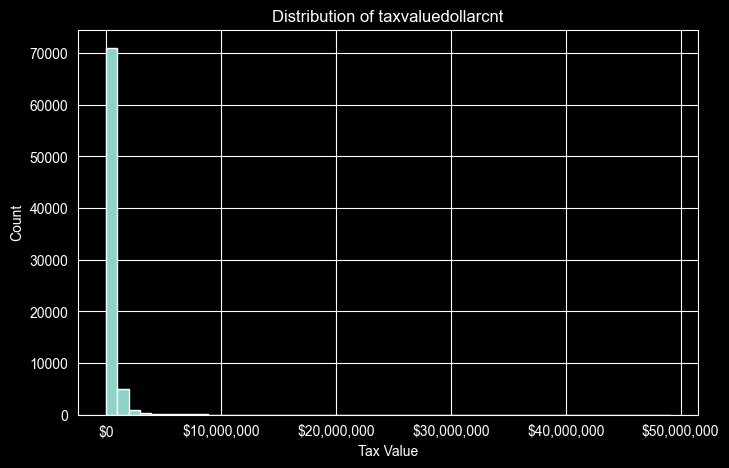

In [6]:
target = 'taxvaluedollarcnt'

print(df[target].describe())

plt.figure(figsize=(8,5))
df[target].hist(bins=50)
plt.title("Distribution of taxvaluedollarcnt")
plt.xlabel("Tax Value")
plt.ylabel("Count")
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(dollar_format))

Text(0, 0.5, 'Percent Missing')

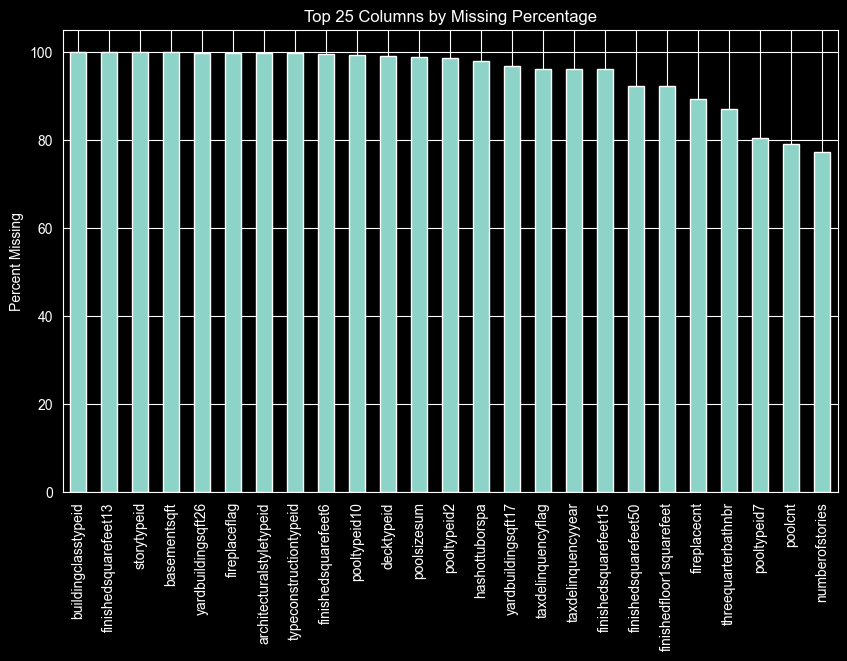

In [7]:
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)

plt.figure(figsize=(10,6))
missing_pct.head(25).plot(kind='bar')
plt.title("Top 25 Columns by Missing Percentage")
plt.ylabel("Percent Missing")

# identifying missing values in the top 25 columns

In [8]:
target = 'taxvaluedollarcnt'

df1 = df.dropna(subset=[target]).copy()


missing_pct = df1.isna().mean()
cols_to_drop_missing = missing_pct[missing_pct > 0.50].index.tolist()


extra_drop = ['parcelid', 'assessmentyear']


extra_drop = [col for col in extra_drop if col in df1.columns]

df1 = df1.drop(columns=cols_to_drop_missing + extra_drop)

print("Dropped for missingness:", cols_to_drop_missing)
print("Dropped additional columns:", extra_drop)
print("New shape:", df1.shape)

#dropping columns with too many NA, dropping fake columns tha tmight exist

Dropped for missingness: ['airconditioningtypeid', 'architecturalstyletypeid', 'basementsqft', 'buildingclasstypeid', 'decktypeid', 'finishedfloor1squarefeet', 'finishedsquarefeet13', 'finishedsquarefeet15', 'finishedsquarefeet50', 'finishedsquarefeet6', 'fireplacecnt', 'garagecarcnt', 'garagetotalsqft', 'hashottuborspa', 'poolcnt', 'poolsizesum', 'pooltypeid10', 'pooltypeid2', 'pooltypeid7', 'regionidneighborhood', 'storytypeid', 'threequarterbathnbr', 'typeconstructiontypeid', 'yardbuildingsqft17', 'yardbuildingsqft26', 'numberofstories', 'fireplaceflag', 'taxdelinquencyflag', 'taxdelinquencyyear']
Dropped additional columns: ['parcelid', 'assessmentyear']
New shape: (77578, 24)


In [9]:
print(df1.isna().sum().sort_values(ascending=False).head(20))

heatingorsystemtypeid           28007
buildingqualitytypeid           27769
propertyzoningdesc              27102
unitcnt                         26875
lotsizesquarefeet                8258
finishedsquarefeet12             3656
regionidcity                     1472
calculatedbathnbr                 616
fullbathcnt                       616
yearbuilt                         270
censustractandblock               247
calculatedfinishedsquarefeet      201
regionidzip                        50
bathroomcnt                         0
roomcnt                             0
regionidcounty                      0
propertycountylandusecode           0
rawcensustractandblock              0
propertylandusetypeid               0
bedroomcnt                          0
dtype: int64


In [10]:
target = 'taxvaluedollarcnt'

df2 = df1.copy()

cols_to_drop_now = ['rawcensustractandblock', 'censustractandblock']
cols_to_drop_now = [col for col in cols_to_drop_now if col in df2.columns]
df2 = df2.drop(columns=cols_to_drop_now)

categorical_like = [
    'buildingqualitytypeid',
    'heatingorsystemtypeid',
    'propertycountylandusecode',
    'propertylandusetypeid',
    'propertyzoningdesc',
    'fips',
    'regionidcity',
    'regionidcounty',
    'regionidzip'
]

categorical_like = [col for col in categorical_like if col in df2.columns]

numeric_cols = [col for col in df2.columns if col not in categorical_like + [target]]

from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

df2[numeric_cols] = num_imputer.fit_transform(df2[numeric_cols])
df2[categorical_like] = cat_imputer.fit_transform(df2[categorical_like])

print("Remaining missing values:")
print(df2.isna().sum().sort_values(ascending=False).head(20))
print("Final shape:", df2.shape)

#checking missing values after imputation

Remaining missing values:
bathroomcnt                     0
bedroomcnt                      0
yearbuilt                       0
unitcnt                         0
roomcnt                         0
regionidzip                     0
regionidcounty                  0
regionidcity                    0
propertyzoningdesc              0
propertylandusetypeid           0
propertycountylandusecode       0
lotsizesquarefeet               0
longitude                       0
latitude                        0
heatingorsystemtypeid           0
fullbathcnt                     0
fips                            0
finishedsquarefeet12            0
calculatedfinishedsquarefeet    0
calculatedbathnbr               0
dtype: int64
Final shape: (77578, 22)


In [11]:
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
df2[categorical_like] = encoder.fit_transform(df2[categorical_like])

In [12]:
for col in df2.columns:
    print(col, df2[col].nunique())

bathroomcnt 22
bedroomcnt 16
buildingqualitytypeid 12
calculatedbathnbr 21
calculatedfinishedsquarefeet 4972
finishedsquarefeet12 4868
fips 3
fullbathcnt 13
heatingorsystemtypeid 10
latitude 64037
longitude 62460
lotsizesquarefeet 18848
propertycountylandusecode 75
propertylandusetypeid 13
propertyzoningdesc 1907
regionidcity 175
regionidcounty 3
regionidzip 389
roomcnt 16
unitcnt 8
yearbuilt 136
taxvaluedollarcnt 50949


In [13]:
target = 'taxvaluedollarcnt'

corr_with_target = df2.corr(numeric_only=True)[target].sort_values(ascending=False)
print(corr_with_target)

taxvaluedollarcnt               1.000000
finishedsquarefeet12            0.592820
calculatedfinishedsquarefeet    0.578629
calculatedbathnbr               0.476760
fullbathcnt                     0.465220
bathroomcnt                     0.461013
buildingqualitytypeid           0.252342
bedroomcnt                      0.239326
yearbuilt                       0.118518
fips                            0.018035
propertycountylandusecode       0.017020
unitcnt                         0.004646
roomcnt                         0.001960
regionidcity                   -0.009764
lotsizesquarefeet              -0.019454
propertyzoningdesc             -0.030864
longitude                      -0.032118
regionidcounty                 -0.040221
propertylandusetypeid          -0.070182
regionidzip                    -0.090216
latitude                       -0.098225
heatingorsystemtypeid          -0.105751
Name: taxvaluedollarcnt, dtype: float64


Text(0.5, 1.0, 'Correlation Heatmap of Top Features')

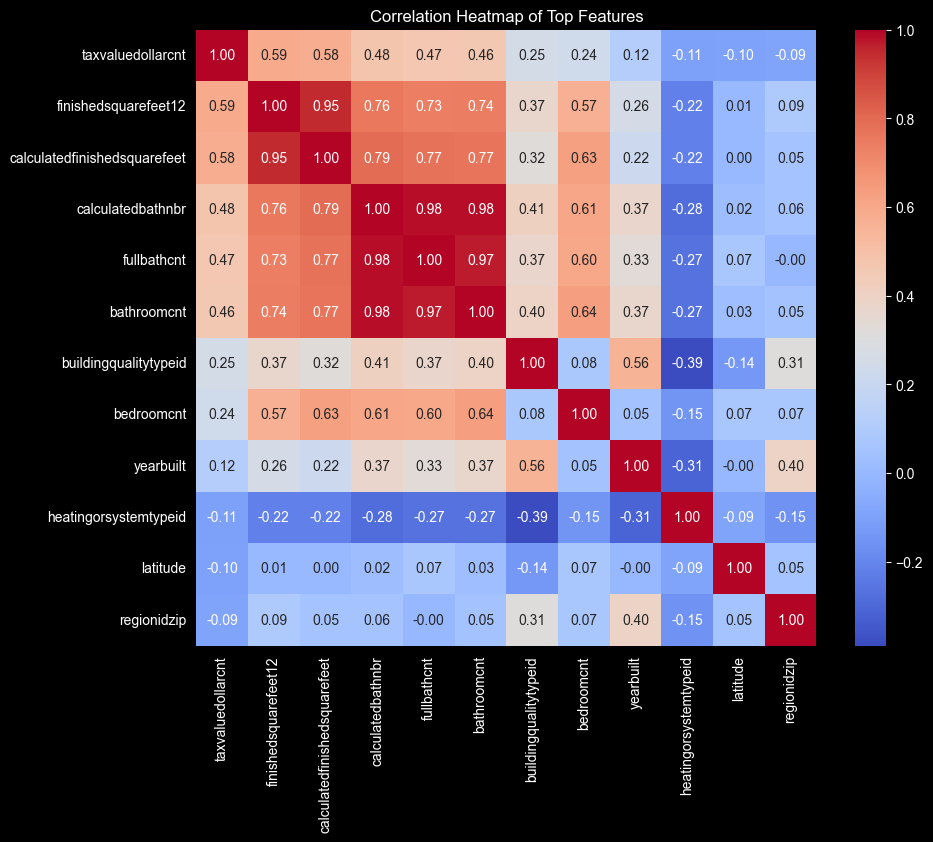

In [14]:

top_corr_features = corr_with_target.abs().sort_values(ascending=False).head(12).index

plt.figure(figsize=(10, 8))
sns.heatmap(df2[top_corr_features].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap of Top Features")

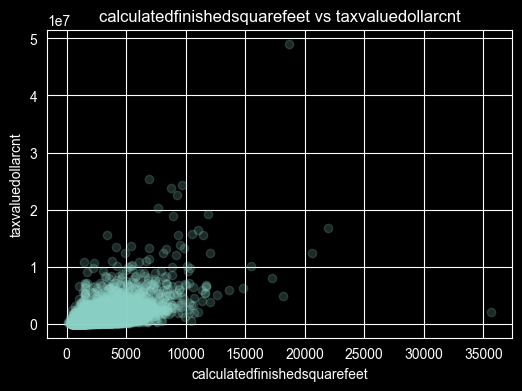

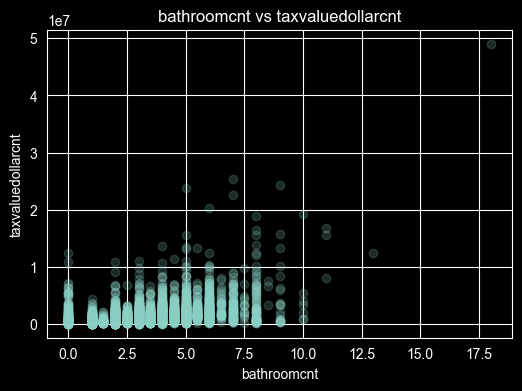

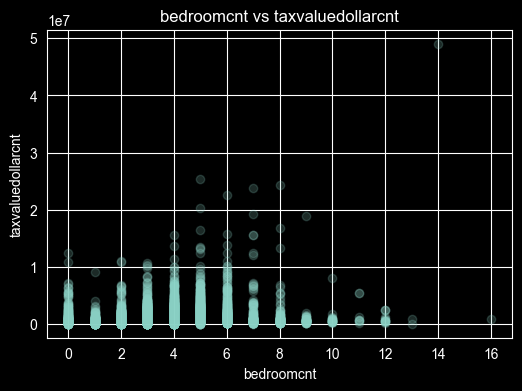

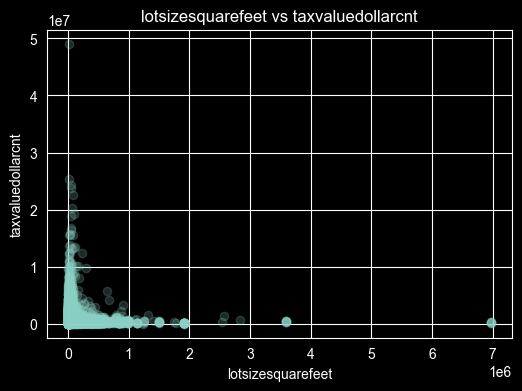

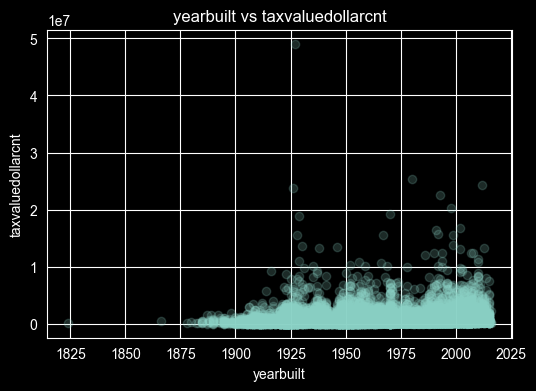

In [15]:
features_to_plot = [
    'calculatedfinishedsquarefeet',
    'bathroomcnt',
    'bedroomcnt',
    'lotsizesquarefeet',
    'yearbuilt'
]

features_to_plot = [col for col in features_to_plot if col in df2.columns]

for col in features_to_plot:
    plt.figure(figsize=(6,4))
    plt.scatter(df2[col], df2[target], alpha=0.2)
    plt.title(f"{col} vs {target}")
    plt.xlabel(col)
    plt.ylabel(target)


## Part 1: Frame the problem and look at the big picture [3 pts]

This part is a bit vague, since this project is not taking place in an actual business, but for the sake of exercizing all the steps, **pretend** that you are working at Zillow as a data analyst and are given this dataset and asked to
- Analyze and understand the data; 
- Create a regression model;
- Give a presentation to the marketing team about your results.  

#### **1 Discussion:** 

AFTER doing your EDA, come back and answer each of the following 3 questions in a *concise and informative paragraph between the lines;* you may wish to use your own business or home-buying experience, or to do some online research about the issues before you propose your ideas. (Don't stress about this, but *humor your professor and give it your best shot!*)


**1.1:**  What is the objective of this project in business terms?

Answer: The objective of the project is to help zillow estimate the assessed tax value of different residential properties. This data greatly supports accurate property valuation and improves overall understanding of which features drive home value. Some potential models that zillow can implement to utilize this include pricing strategy models, customer-based analytics, and similarities/trends amongst higher priced homes (to target people who are actively in the market/people who are able to buy). 

**1.2:**  How will your solution be used?

Answer: This solution will be used as a decision support tool that will support decisions revolving around the models mentioned in 1.1. Analysts would use it to generate predicted property values for homes in the dataset, compare predicted values to recorded assessed values, and identify the most influential property features. Finding trends that are associated with high priced homes would be crucial to see adequate target populations. These models aid the creation of pricing trends, and can support internal business decisions more efficiently. 


**1.3:**  How should success (or failure) be measured?

Answer: Success for these models should be considered by how accurate and consistent the predictions are, specifically, the predictions on the unseen/unknown data. Some metrics that can be used to evaluate these regression models are RMSE and MAE-- useful for assessing how accurate the predicitons are. Large prediction errors would signify failure, while the correct identification of which home features matter the most to the client would demonstrate success. The key is identfying wihch features accurately predict market trends. 


## Part 2: Download and perform preliminary exploration of the data [4 pts]

### Part 2.A: Load the data into a dataframe and study each feature/column and its characteristics:
- Name
- Type (categorical, int/float, text, etc.)
- Apparent usefulness for the task
- Approximate % of missing values
- How many unique values

**Note:** The **target** is the last column `'taxvaluedollarcnt'` -- pay particular attention to this during the EDA process. 
  
Hint: Just use `.head()`, `.info()`, and `.nunique()`.

In [16]:
summary = pd.DataFrame({
    'column_name': df.columns,
    'dtype': df.dtypes.values,
    'missing_count': df.isna().sum().values,
    'missing_percent': (df.isna().mean().values * 100),
    'unique_values': df.nunique().values
})


def classify_feature(col):
    if col == 'taxvaluedollarcnt':
        return 'target (numeric)'
    elif df[col].dtype == 'object':
        return 'categorical/text'
    elif pd.api.types.is_integer_dtype(df[col]):
        return 'integer'
    elif pd.api.types.is_float_dtype(df[col]):
        return 'float'
    else:
        return 'other'

summary['feature_type'] = summary['column_name'].apply(classify_feature)

def usefulness(col):
    if col == 'taxvaluedollarcnt':
        return 'Target variable'
    elif col in ['parcelid', 'rawcensustractandblock', 'censustractandblock']:
        return 'Likely low usefulness / identifier-like'
    elif col in ['bathroomcnt', 'bedroomcnt', 'calculatedfinishedsquarefeet',
                 'finishedsquarefeet12', 'yearbuilt', 'lotsizesquarefeet',
                 'regionidcity', 'regionidzip', 'buildingqualitytypeid']:
        return 'Likely useful'
    elif df[col].isna().mean() > 0.50:
        return 'Possibly low usefulness due to high missingness'
    else:
        return 'Potentially useful'

summary['apparent_usefulness'] = summary['column_name'].apply(usefulness)

summary = summary.sort_values(by='missing_percent', ascending=False)
summary

,column_name,dtype,missing_count,missing_percent,unique_values,feature_type,apparent_usefulness
6,buildingclasstypeid,float64,77598,99.980673,2,float,Possibly low usefulness due to high missingness
13,finishedsquarefeet13,float64,77571,99.945885,13,float,Possibly low usefulness due to high missingness
41,storytypeid,float64,77563,99.935578,1,float,Possibly low usefulness due to high missingness
3,basementsqft,float64,77563,99.935578,43,float,Possibly low usefulness due to high missingness
46,yardbuildingsqft26,float64,77543,99.909809,59,float,Possibly low usefulness due to high missingness
49,fireplaceflag,object,77441,99.778388,1,categorical/text,Possibly low usefulness due to high missingness
2,architecturalstyletypeid,float64,77406,99.733292,5,float,Possibly low usefulness due to high missingness
43,typeconstructiontypeid,float64,77390,99.712677,4,float,Possibly low usefulness due to high missingness
16,finishedsquarefeet6,float64,77227,99.502661,350,float,Possibly low usefulness due to high missingness
29,pooltypeid10,float64,77148,99.400874,1,float,Possibly low usefulness due to high missingness


#### **2.A Discussion:** Answer the following questions.

**2.A.1:**  Which features are categorical?

Answer: The categorical columns are shown above and are labeled as "categorical" in the feature type column.

**2.A.2:**  Are there any features which appear at first glance to be **useless** for the business purpose of this project and should be deleted?  Give examples and describe your reasoning briefly. 

Answer: There are some features that appeat to be low-value for predictions because they behave more like identifiers rather than meaningful property characteristics. ParcelID is a unique identifier, which is not too useful itself for describing home itself. Similarly, rawcencustractandblock and censustractandblock are moreso identifiers for geographic regions as opposed to home attributes. 

**2.A.3:**  Are there any features which appear to be **useless** because of the percentage of missing values?  If so, give an example. 

Answer: Yes, there are several features that appear to be low-value because they are missing almost all of their data. For example, buildingclasstypeid is missing about 99.98% of its values, while finishedsquarefeet13, basementsqft, and storytypeid are each missing about 99.9%. Since these features contain so little actual information, they are unlikely to contribute much to the prediction task and are strong candidates for deletion. My group decided to count anything over 75% missing as significant.

**2.A.4:**  Are there any features which appear to be **useless** because of the number of unique values?  If so, give an example. 

Answer: Yes. Some features appear unhelpful because they have little to no variation in their values. For example, assessmentyear has only one unique value, which makes it effectively constant and not useful for modeling. Other features such as decktypeid, pooltypeid10, pooltypeid2, pooltypeid7, fireplaceflag, hashottuborspa, and taxdelinquencyflag also have only one unique non-missing value, so they provide very limited predictive value

### Part 2.B: Exploratory Data Analysis (EDA) -- Feature-Level Visualization  

- To get an overview, generate histograms for all features using `df.hist()`  (Hint: increase the figsize and set the layout to `(-1,m)` to get  `m` columns and as many rows as necessary.)
- Generate individual visualizations for the **target and three (3)** other interesting-looking features in the dataset (i.e., a total of 4):  
    - Use appropriate plot types (e.g., histograms and boxplots for numerical features, bar plots for categorical features) to understand distributions and identify potential outliers for these three.
    - Use as many code cells as you need, and give comments describing what each cell does.
    - Answer the discussion question posed (you should choose 3 features for which you can say something interesting in the discussion).  

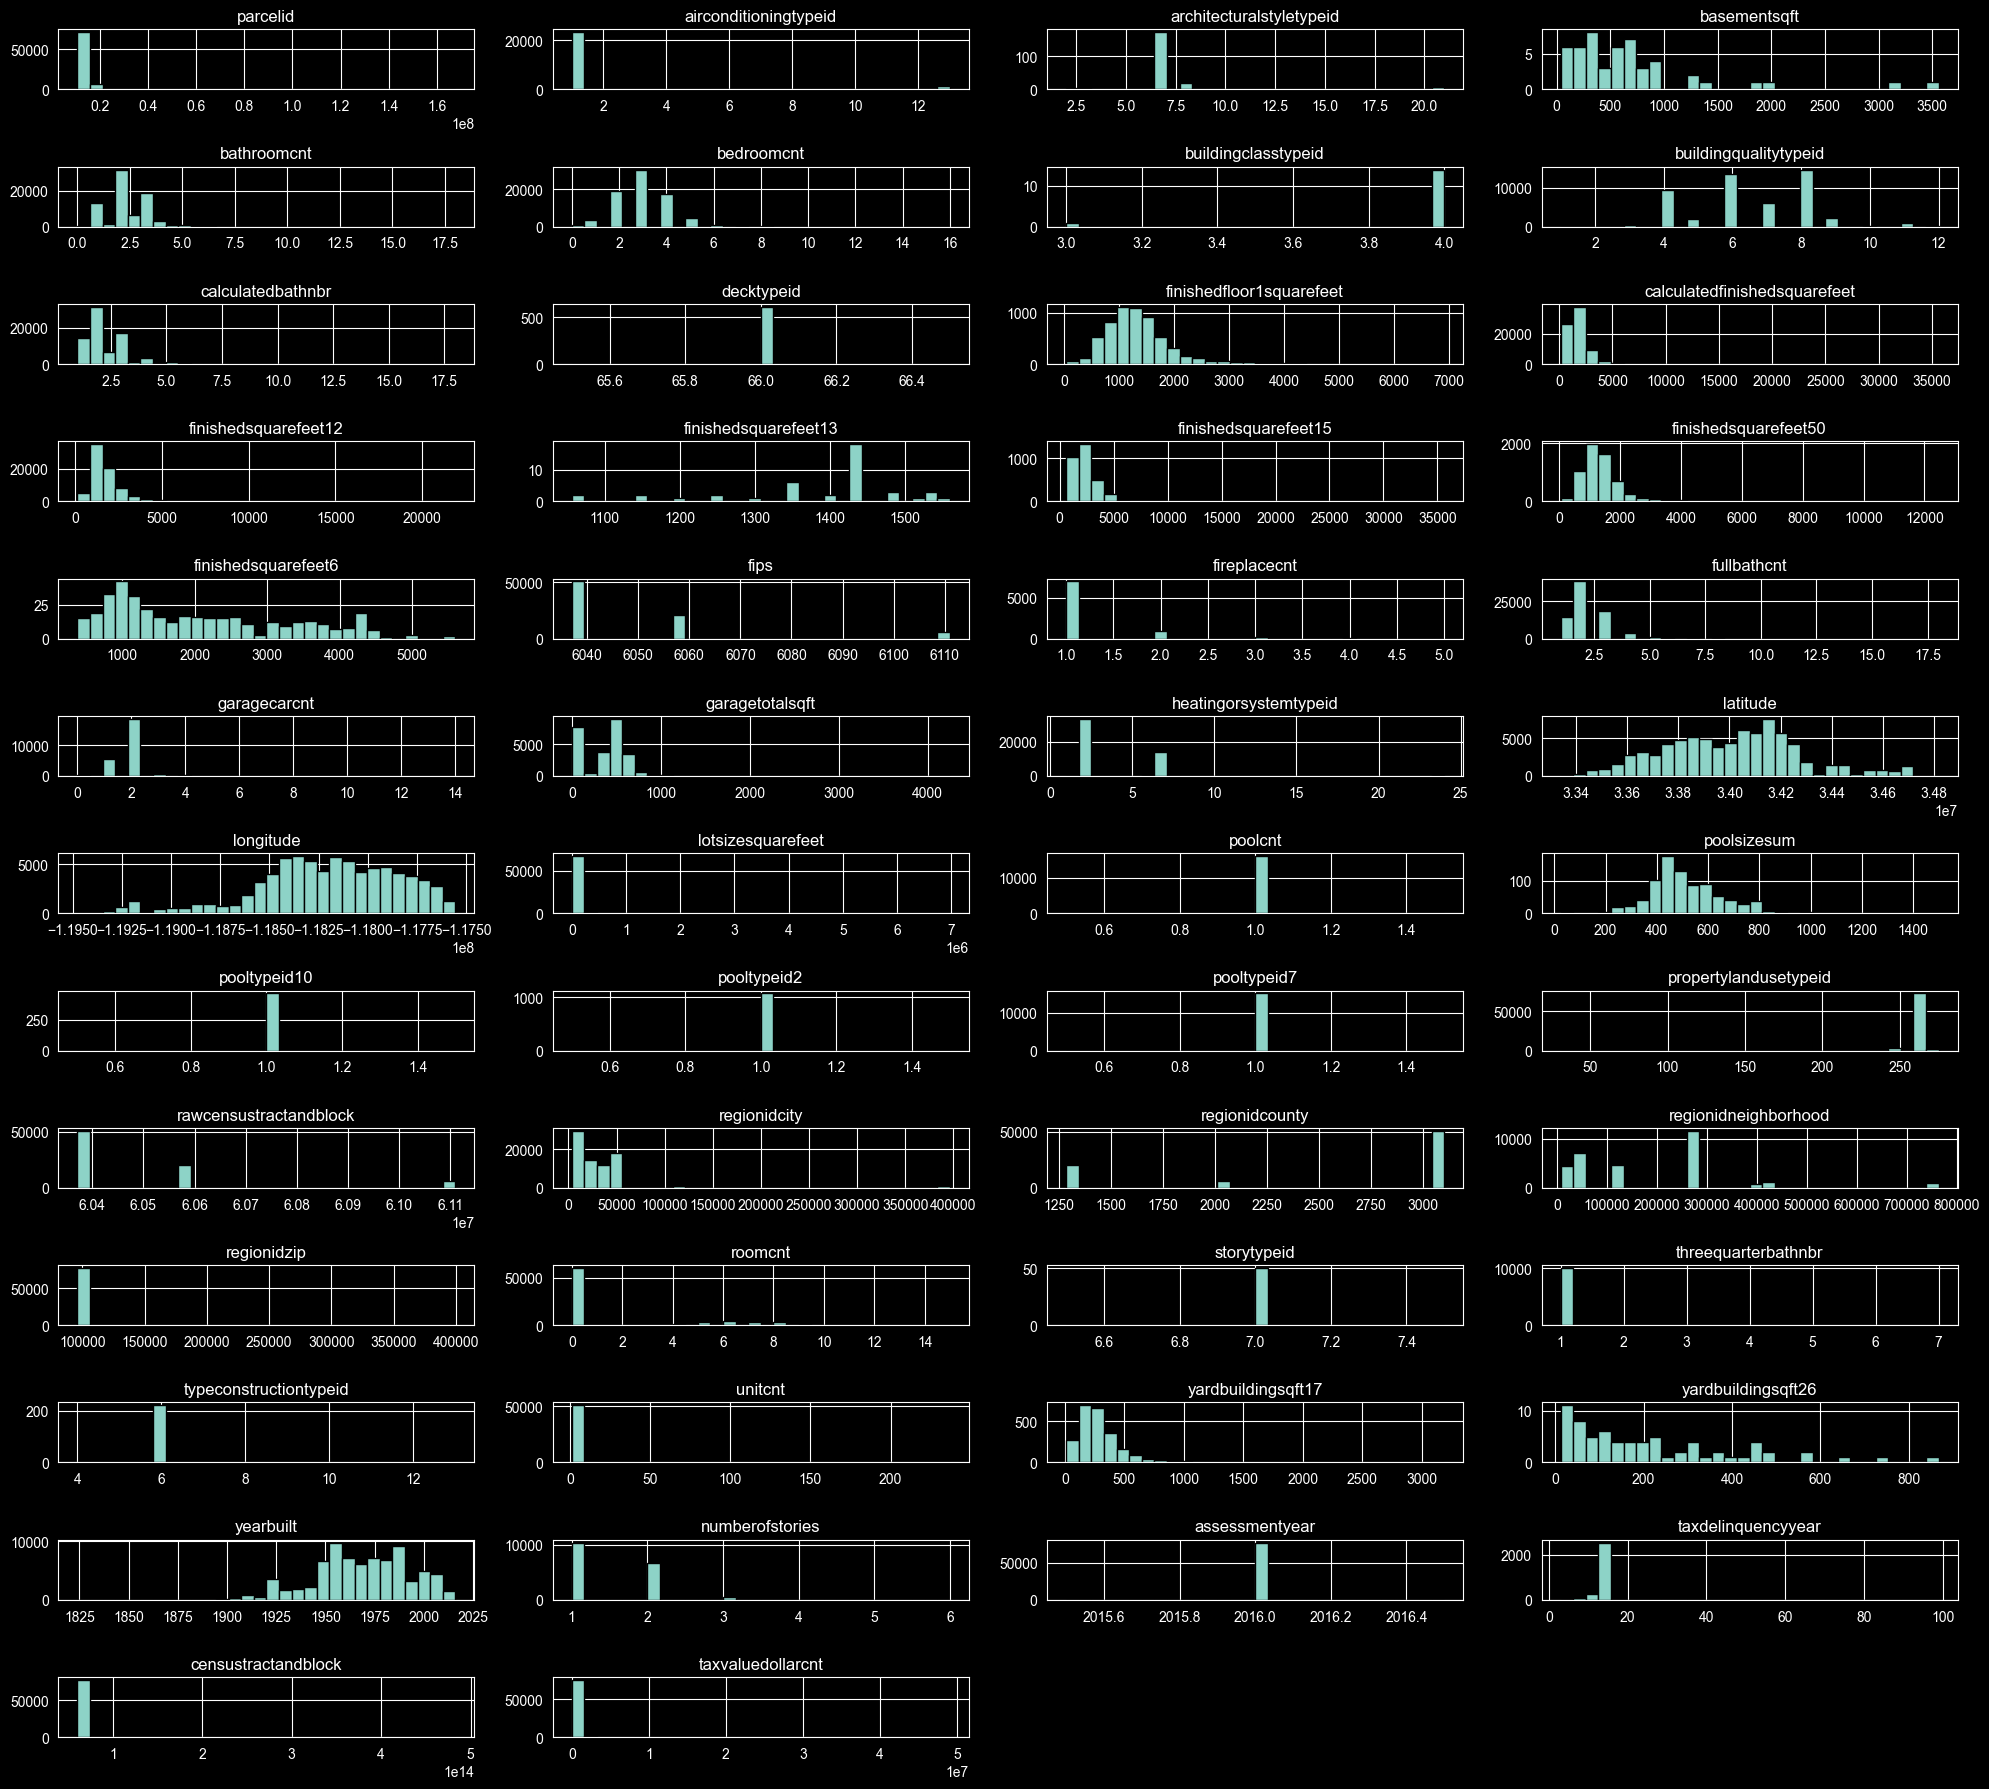

In [17]:
# a histogram for all numeric features to get an overall sense of distributions
df.hist(figsize=(20, 18), layout=(-1, 4), bins=30, edgecolor='black')
plt.tight_layout()

Text(0, 0.5, 'Count')

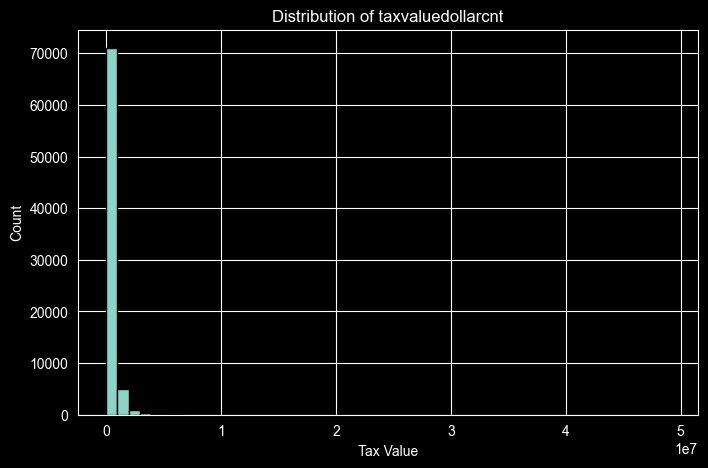

In [18]:
#target histogram 

plt.figure(figsize=(8,5))
plt.hist(df['taxvaluedollarcnt'].dropna(), bins=50, edgecolor='black')
plt.title('Distribution of taxvaluedollarcnt')
plt.xlabel('Tax Value')
plt.ylabel('Count')

Text(0.5, 0, 'Tax Value')

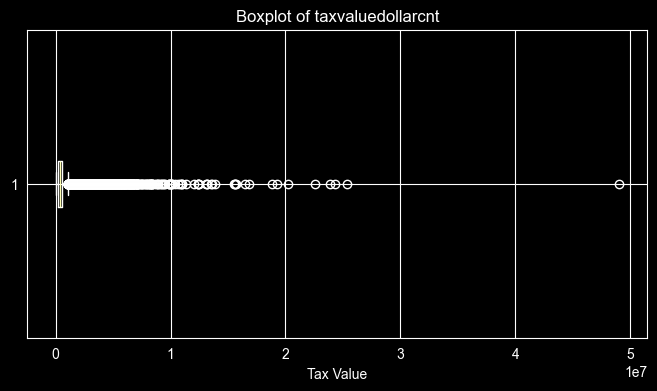

In [19]:
#target boxpot
plt.figure(figsize=(8,4))
plt.boxplot(df['taxvaluedollarcnt'].dropna(), vert=False)
plt.title('Boxplot of taxvaluedollarcnt')
plt.xlabel('Tax Value')

Text(0, 0.5, 'Count')

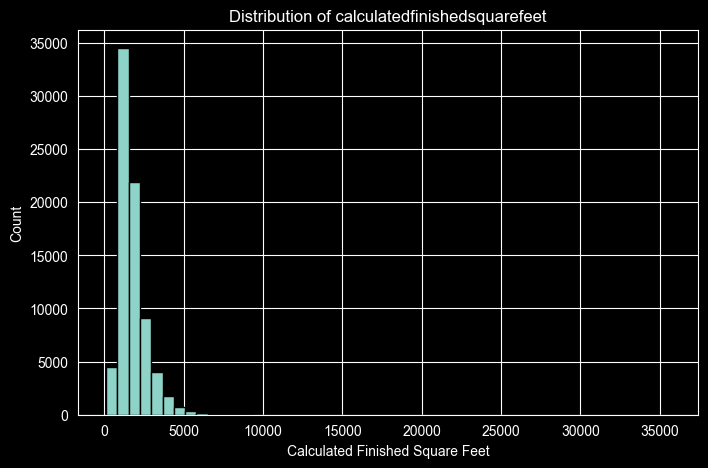

In [20]:
#histogram of calculated finished squarefeet
plt.figure(figsize=(8,5))
plt.hist(df['calculatedfinishedsquarefeet'].dropna(), bins=50, edgecolor='black')
plt.title('Distribution of calculatedfinishedsquarefeet')
plt.xlabel('Calculated Finished Square Feet')
plt.ylabel('Count')

Text(0.5, 0, 'Calculated Finished Square Feet')

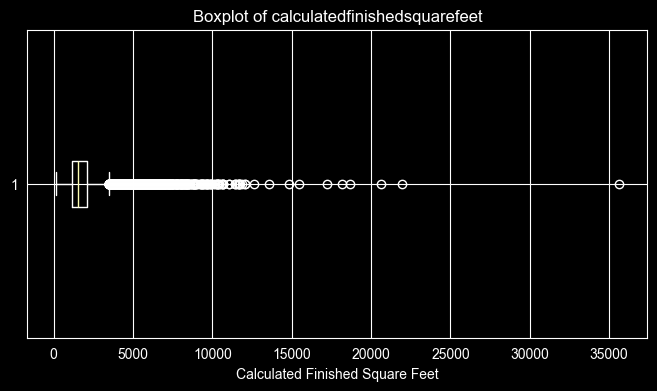

In [21]:
#boxplot of calculated finished square feet
plt.figure(figsize=(8,4))
plt.boxplot(df['calculatedfinishedsquarefeet'].dropna(), vert=False)
plt.title('Boxplot of calculatedfinishedsquarefeet')
plt.xlabel('Calculated Finished Square Feet')

Text(0, 0.5, 'Count')

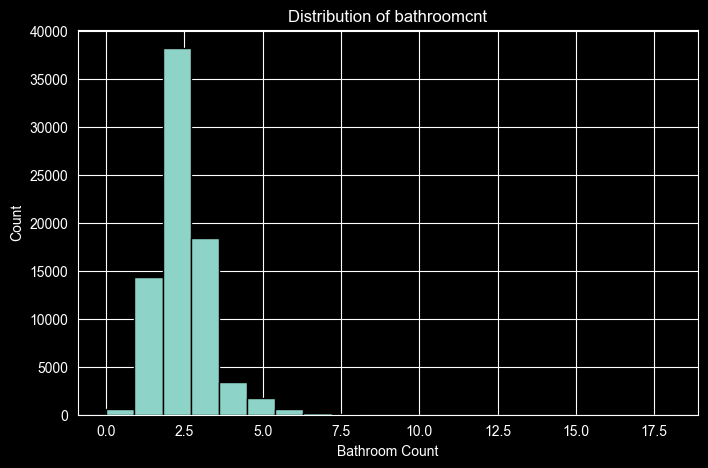

In [22]:
#histogram of bathroom count
plt.figure(figsize=(8,5))
plt.hist(df['bathroomcnt'].dropna(), bins=20, edgecolor='black')
plt.title('Distribution of bathroomcnt')
plt.xlabel('Bathroom Count')
plt.ylabel('Count')

Text(0.5, 1.0, 'Boxplot of bathroomcnt')

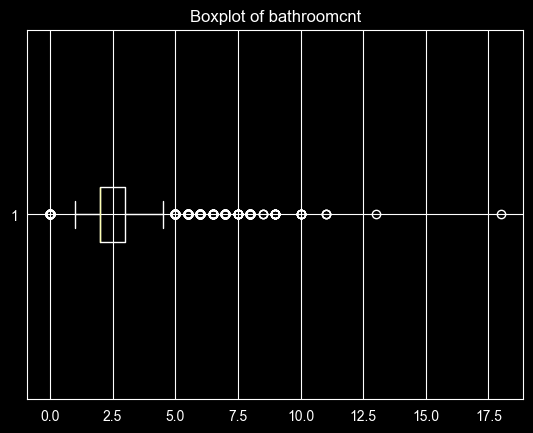

In [23]:
#boxplot of bathroom count
plt.boxplot(df['bathroomcnt'].dropna(), vert=False)
plt.title('Boxplot of bathroomcnt')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 [Text(0, 0, '1.0'),
  Text(1, 0, '2.0'),
  Text(2, 0, '3.0'),
  Text(3, 0, '4.0'),
  Text(4, 0, '5.0'),
  Text(5, 0, '6.0'),
  Text(6, 0, '7.0'),
  Text(7, 0, '8.0'),
  Text(8, 0, '9.0'),
  Text(9, 0, '10.0'),
  Text(10, 0, '11.0'),
  Text(11, 0, '12.0')])

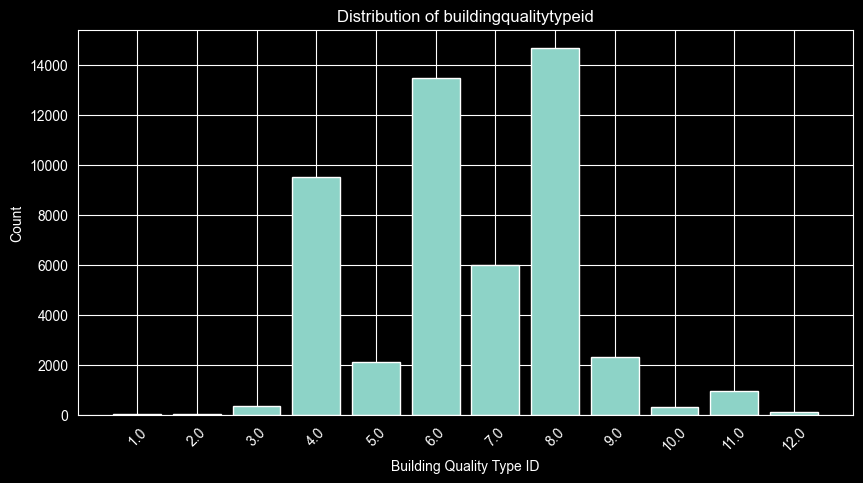

In [24]:
#barplot of buiilding quality type
quality_counts = df['buildingqualitytypeid'].value_counts().sort_index()

plt.figure(figsize=(10,5))
plt.bar(quality_counts.index.astype(str), quality_counts.values)
plt.title('Distribution of buildingqualitytypeid')
plt.xlabel('Building Quality Type ID')
plt.ylabel('Count')
plt.xticks(rotation=45)

#### **2.B Discussion:** Describe in a paragraph what you learned in your detailed examination of the features you explored:
- What is the distribution (normal, exponential, etc.) if any?
- Any problems (e.g., outliers, any odd characteristics)?
- Anything else interesting? Why did you choose it?


In my detailed examination, I chose taxvaluedollarcnt, calculatedfinishedsquarefeet, bathroomcnt, and buildingqualitytypeid because they seemed like some of the most relevant features for predicting home value. Both taxvaluedollarcnt and calculatedfinishedsquarefeet have strongly right-skewed distributions, with most observations concentrated at lower values and a smaller number of very large outliers. The boxplots also confirm that both variables contain many extreme values, which could affect regression modeling later on. bathroomcnt is also right-skewed, though less extreme, with most homes having around 2 to 3 bathrooms and a few unusual homes having very high bathroom counts. buildingqualitytypeid is interesting because it does not follow a continuous numeric distribution and instead behaves more like a categorical code, with some categories appearing much more often than others. Overall, these plots show that skewness, outliers, and coded categorical variables are all important characteristics of this dataset and will need to be handled carefully in later modeling steps.

## Part 3:  Clean the Data: Drop, Impute, and Encode [6 pts]



**Important Notes:**
- You should review your Homework 4 before doing this section!
- Create new names for modified data at each stage to avoid problems with global variables.
- Whenever possible, write functions for all data transformations you apply, for these reasons:
    - So you can easily prepare the data the next time you get a fresh dataset
    - So you can apply these transformations in future projects
    - To clean and prepare new data instances once your solution is live
    - To make it easy to treat your preparation choices as hyperparameters
    - [To apply the same transformations to your test set if train/test split already done -- not applicable here]

### Part 3.A: Drop features you judge to be unsuitable for the regression task

Your call, based on any research you can do to understand the feature (hopefully IRL you would have a domain expert to help with this, but do your best).   

Note: Do not drop features because of too many missing values, that's the next task! 

In [25]:

def drop_unsuitable_features(df):
    cols_to_drop = [
        'parcelid',
        'rawcensustractandblock',
        'censustractandblock',
        'assessmentyear'
    ]
    
    cols_to_drop = [col for col in cols_to_drop if col in df.columns]
    df_dropped = df.drop(columns=cols_to_drop).copy()
    
    return df_dropped, cols_to_drop

df_part3a, dropped_cols = drop_unsuitable_features(df)

print("Dropped columns:", dropped_cols)
print("New shape:", df_part3a.shape)

Dropped columns: ['parcelid', 'rawcensustractandblock', 'censustractandblock', 'assessmentyear']
New shape: (77613, 51)


#### **3.A Discussion:** Justify in a paragraph your decisions about which features to drop. 


Answer: I dropped features that appeared unsuitable for regression regardless of their missingness. parcelid was removed because it is a unique identifier for each property and does not describe the home itself. I also dropped rawcensustractandblock and censustractandblock because they behave more like geographic identifier codes than meaningful property characteristics, and their extremely high number of unique values makes them less interpretable for this task. Finally, assessmentyear was dropped because it is effectively constant in this dataset, so it does not provide useful variation for predicting taxvaluedollarcnt. Overall, these features were removed because they are low-value for modeling and are unlikely to improve prediction quality. 

Note: These features were mentioned earlier in section 2.A.2.

### Part 3.B: Drop **features** with "too many" null values

Your code in the next cell(s). Make a judgement call about what "too many" means and briefly describe your reasoning in the discussion.   

Note: "Too many" may depend on what the non-null values look like, be sure to investigate carefully. 

In [26]:
#dropping features with too many values

def drop_high_missing_features(df, threshold=0.70):
    missing_fraction = df.isna().mean()
    cols_to_drop = missing_fraction[missing_fraction > threshold].index.tolist()
    df_reduced = df.drop(columns=cols_to_drop).copy()
    return df_reduced, cols_to_drop, missing_fraction

df_part3b, dropped_missing_cols, missing_fraction = drop_high_missing_features(df_part3a, threshold=0.70)

print("Dropped columns for high missingness:")
print(dropped_missing_cols)
print("\nNew shape:", df_part3b.shape)

Dropped columns for high missingness:
['architecturalstyletypeid', 'basementsqft', 'buildingclasstypeid', 'decktypeid', 'finishedfloor1squarefeet', 'finishedsquarefeet13', 'finishedsquarefeet15', 'finishedsquarefeet50', 'finishedsquarefeet6', 'fireplacecnt', 'hashottuborspa', 'poolcnt', 'poolsizesum', 'pooltypeid10', 'pooltypeid2', 'pooltypeid7', 'storytypeid', 'threequarterbathnbr', 'typeconstructiontypeid', 'yardbuildingsqft17', 'yardbuildingsqft26', 'numberofstories', 'fireplaceflag', 'taxdelinquencyflag', 'taxdelinquencyyear']

New shape: (77613, 26)


In [27]:
pd.DataFrame({
    "column": dropped_missing_cols,
    "missing_percent": [missing_fraction[col] * 100 for col in dropped_missing_cols]
}).sort_values(by="missing_percent", ascending=False)

#visualization of what was dropped.

,column,missing_percent
2,buildingclasstypeid,99.980673
5,finishedsquarefeet13,99.945885
1,basementsqft,99.935578
16,storytypeid,99.935578
20,yardbuildingsqft26,99.909809
22,fireplaceflag,99.778388
0,architecturalstyletypeid,99.733292
18,typeconstructiontypeid,99.712677
8,finishedsquarefeet6,99.502661
13,pooltypeid10,99.400874


#### **3.B Discussion:** In a paragraph, explain your decision about which features were dropped



My group and I defined “too many” missing values as more than 70% of the entries in a feature being null. The team chose this cutoff in order to avoid introducing unecessary noise into the model. Many of the removed columns in this dataset had extremely high missingness, often above 80% or even 99%, so they were unlikely to provide enough information to justify keeping them. Using a 70% threshold allowed me to keep features that still had meaningful coverage while removing features with too little usable data.

### Part 3.C: Drop Problematic **samples** 

There could be several reasons why you might want to drop a sample:
- It has  "too many" null values 
- It has a null value in the target
- It contains outliers, especially in the target



Your code in the next cell(s). Make a judgement call about which samples should be dropped and briefly describe your reasoning in the discussion.   


In [28]:
# Inspect row-level missingness before choosing a threshold
row_null_counts = df_part3b.isna().sum(axis=1)

print("Row null count summary:")
print(row_null_counts.describe())

print("\nRows by number of missing values:")
print(row_null_counts.value_counts().sort_index())

Row null count summary:
count    77613.000000
mean         4.239960
std          1.734983
min          2.000000
25%          3.000000
50%          4.000000
75%          6.000000
max         26.000000
dtype: float64

Rows by number of missing values:
2     10457
3     22609
4     15040
5      6852
6     16404
7      4661
8       889
9       374
10       81
11       42
12       37
13       82
14       45
15        6
26       34
Name: count, dtype: int64


In [29]:
#dropping problematic samples-- rows that have 8 or more nulls at 0.30. 

def drop_problematic_samples(df, target='taxvaluedollarcnt', row_missing_threshold=0.30):
    df_out = df.copy()
    
    # missing target rows
    missing_target_mask = df_out[target].isna()
    n_missing_target = missing_target_mask.sum()
    df_out = df_out.loc[~missing_target_mask].copy()
    
    # missing values in rows as specified by the threshold
    row_missing_fraction = df_out.isna().mean(axis=1)
    too_many_nulls_mask = row_missing_fraction > row_missing_threshold
    n_too_many_nulls = too_many_nulls_mask.sum()
    df_out = df_out.loc[~too_many_nulls_mask].copy()
    
    summary = {
        "dropped_missing_target": int(n_missing_target),
        "dropped_too_many_nulls": int(n_too_many_nulls),
        "final_shape": df_out.shape
    }
    
    return df_out, summary

df_part3c, sample_drop_summary = drop_problematic_samples(
    df_part3b, target='taxvaluedollarcnt', row_missing_threshold=0.30
)

print(sample_drop_summary)

{'dropped_missing_target': 35, 'dropped_too_many_nulls': 1556, 'final_shape': (76022, 26)}


#### **3.C Discussion:** In a short paragraph, explain your decision about which samples were dropped


I dropped rows that were clearly problematic for modeling. First, I removed any samples with a missing value in the target variable, since a regression model cannot be trained without a valid target. Next, I examined row-level missingness and dropped rows with more than 30% missing values among the remaining features, since those rows contained too little usable information and would require excessive imputation. I chose not to automatically drop target outliers at this stage, because in a housing dataset very large tax values may represent legitimate luxury properties rather than data errors. Instead, I treated the extreme values as something to monitor during later modeling and evaluation.

### Part 3.D: Impute for the remaining missing values

Review the methods for imputation in **Appendix 2** and choose how you will impute the remainder of the missing values. Note:
- Consider whether different methods are justified for different features.
- In the next cells, apply your imputation methods to the dataset so that no null values remain after this step.
- Answer the discussion question.

In [30]:


def impute_remaining_missing_values(df, target='taxvaluedollarcnt'):
    df_out = df.copy()

    # categorical-like columns that should be imputed with most frequent
    categorical_like = [
        'buildingqualitytypeid',
        'heatingorsystemtypeid',
        'propertycountylandusecode',
        'propertylandusetypeid',
        'propertyzoningdesc',
        'fips',
        'regionidcity',
        'regionidcounty',
        'regionidzip'
    ]

    categorical_like = [col for col in categorical_like if col in df_out.columns]

    # specifying numeric columns as everything except the target
    numeric_cols = [col for col in df_out.columns if col not in categorical_like + [target]]

    
    num_imputer = SimpleImputer(strategy='median')
    cat_imputer = SimpleImputer(strategy='most_frequent')

    # imputations
    if numeric_cols:
        df_out[numeric_cols] = num_imputer.fit_transform(df_out[numeric_cols])

    if categorical_like:
        df_out[categorical_like] = cat_imputer.fit_transform(df_out[categorical_like])

    return df_out, numeric_cols, categorical_like

In [31]:
df_part3d, numeric_cols_used, categorical_cols_used = impute_remaining_missing_values(
    df_part3c,
    target='taxvaluedollarcnt'
)

print("Numeric columns imputed with median:")
print(numeric_cols_used)

print("\nCategorical/code-like columns imputed with most frequent value:")
print(categorical_cols_used)

print("\nRemaining missing values by column:")
print(df_part3d.isna().sum().sort_values(ascending=False))

print("\nTotal remaining missing values in dataset:", df_part3d.isna().sum().sum())
print("Shape after Part 3.D:", df_part3d.shape)

Numeric columns imputed with median:
['airconditioningtypeid', 'bathroomcnt', 'bedroomcnt', 'calculatedbathnbr', 'calculatedfinishedsquarefeet', 'finishedsquarefeet12', 'fullbathcnt', 'garagecarcnt', 'garagetotalsqft', 'latitude', 'longitude', 'lotsizesquarefeet', 'regionidneighborhood', 'roomcnt', 'unitcnt', 'yearbuilt']

Categorical/code-like columns imputed with most frequent value:
['buildingqualitytypeid', 'heatingorsystemtypeid', 'propertycountylandusecode', 'propertylandusetypeid', 'propertyzoningdesc', 'fips', 'regionidcity', 'regionidcounty', 'regionidzip']

Remaining missing values by column:
airconditioningtypeid           0
bathroomcnt                     0
yearbuilt                       0
unitcnt                         0
roomcnt                         0
regionidzip                     0
regionidneighborhood            0
regionidcounty                  0
regionidcity                    0
propertyzoningdesc              0
propertylandusetypeid           0
propertycountyla

In [32]:
assert df_part3d.isna().sum().sum() == 0, "There are still missing values remaining."
print("Success: no missing values remain after imputation.")

Success: no missing values remain after imputation.


#### **3.D Discussion:**  Describe in a paragraph your decisions about which methods you used to impute missing values in the dataset


I used different imputation methods depending on the type of feature. For numeric variables such as bathroomcnt, bedroomcnt, lotsizesquarefeet, yearbuilt, and calculatedfinishedsquarefeet, I used median imputation because these variables are skewed and contain outliers, so the median is more robust than the mean. For categorical or code-like variables such as buildingqualitytypeid, heatingorsystemtypeid, propertycountylandusecode, propertylandusetypeid, propertyzoningdesc, regionidcity, and regionidzip, I used most frequent imputation because these features represent labels or categories rather than continuous measurements. This approach allowed me to preserve the structure of each feature type while ensuring that no null values remained in the dataset after preprocessing.

### 3.E: Encode the Categorical Features (if any)

You may not have any categorical features. If you do, encode them in the next step. No discussion is necessary. 

In [33]:


def encode_categorical_features(df, target='taxvaluedollarcnt', one_hot_max_unique=100):
    df_out = df.copy()

    # object/text columns only
    object_cols = df_out.select_dtypes(include=['object']).columns.tolist()

    # splitting by cardinality
    low_cardinality_cols = [col for col in object_cols if df_out[col].nunique() <= one_hot_max_unique]
    high_cardinality_cols = [col for col in object_cols if df_out[col].nunique() > one_hot_max_unique]

    # encode high cardinality text columns (-1 for unknown)
    if high_cardinality_cols:
        encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
        df_out[high_cardinality_cols] = encoder.fit_transform(df_out[high_cardinality_cols])

    # One-hot encode lower-cardinality text columns
    if low_cardinality_cols:
        df_out = pd.get_dummies(df_out, columns=low_cardinality_cols, drop_first=True)

    return df_out, object_cols, low_cardinality_cols, high_cardinality_cols

In [34]:
df_part3e, object_cols_found, low_card_cols, high_card_cols = encode_categorical_features(df_part3d)

print("Original object/text columns:", object_cols_found)
print("One-hot encoded columns:", low_card_cols)
print("Ordinal encoded columns:", high_card_cols)

print("\nRemaining object columns:")
print(df_part3e.select_dtypes(include=['object']).columns.tolist())

print("\nFinal shape after encoding:", df_part3e.shape)

Original object/text columns: ['buildingqualitytypeid', 'fips', 'heatingorsystemtypeid', 'propertycountylandusecode', 'propertylandusetypeid', 'propertyzoningdesc', 'regionidcity', 'regionidcounty', 'regionidzip']
One-hot encoded columns: ['buildingqualitytypeid', 'fips', 'heatingorsystemtypeid', 'propertycountylandusecode', 'propertylandusetypeid', 'regionidcounty']
Ordinal encoded columns: ['propertyzoningdesc', 'regionidcity', 'regionidzip']

Remaining object columns:
[]

Final shape after encoding: (76022, 119)


In [35]:


def encode_all_object_columns(df):
    df_out = df.copy()
    object_cols = df_out.select_dtypes(include=['object']).columns.tolist()

    if object_cols:
        encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
        df_out[object_cols] = encoder.fit_transform(df_out[object_cols])

    return df_out, object_cols

df_part3e_simple, encoded_cols = encode_all_object_columns(df_part3d)

print("Encoded object columns:", encoded_cols)
print("Remaining object columns:", df_part3e_simple.select_dtypes(include=['object']).columns.tolist())
print("Final shape:", df_part3e_simple.shape)

Encoded object columns: ['buildingqualitytypeid', 'fips', 'heatingorsystemtypeid', 'propertycountylandusecode', 'propertylandusetypeid', 'propertyzoningdesc', 'regionidcity', 'regionidcounty', 'regionidzip']
Remaining object columns: []
Final shape: (76022, 26)


## Part 4:  Investigate Feature Relationships  [6 pts]

In this part, we will investigate the feature relationships as a way of understanding the data.  In the next part, we'll investigate potential feature engineering opportunities.

**Note:**  We won't be committing to any changes to the data until Milestone 2, as our choice of transformations will very much depend on the model we're building. But investigating these aspects of the data is an essential step in the first stages of our project. 

### Part 4.A:

   - Compute and analyze pairwise correlations using a correlation matrix.
   - Compute the F-statistic for all features for a better view of the relationships (displaying them in a bar chart would be useful as well). 
   - Identify features with strong correlations or notable relationships that may impact model performance.
   - Investigate forward and backward feature selection
        - Run these algorithms to investigate possible feature selection (don't commit to any selections yet)

Your code below, in multiple cells with descriptive comments. 

In [36]:

df_part4 = df_part3e.copy()

target = 'taxvaluedollarcnt'
X = df_part4.drop(columns=[target])
y = df_part4[target]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (76022, 118)
Target shape: (76022,)


In [37]:
# correlation matrix
corr_matrix = df_part4.corr(numeric_only=True)

# Correlation of each feature with the target
target_corr = corr_matrix[target].drop(target).sort_values(key=np.abs, ascending=False)

print("Feature correlations with taxvaluedollarcnt:")
print(target_corr)

Feature correlations with taxvaluedollarcnt:
finishedsquarefeet12              0.600848
calculatedfinishedsquarefeet      0.590216
calculatedbathnbr                 0.484848
bathroomcnt                       0.482717
fullbathcnt                       0.472851
                                    ...   
propertycountylandusecode_020M   -0.000161
propertycountylandusecode_040G   -0.000110
propertycountylandusecode_0401    0.000064
propertycountylandusecode_0203    0.000045
propertycountylandusecode_012E   -0.000034
Name: taxvaluedollarcnt, Length: 118, dtype: float64


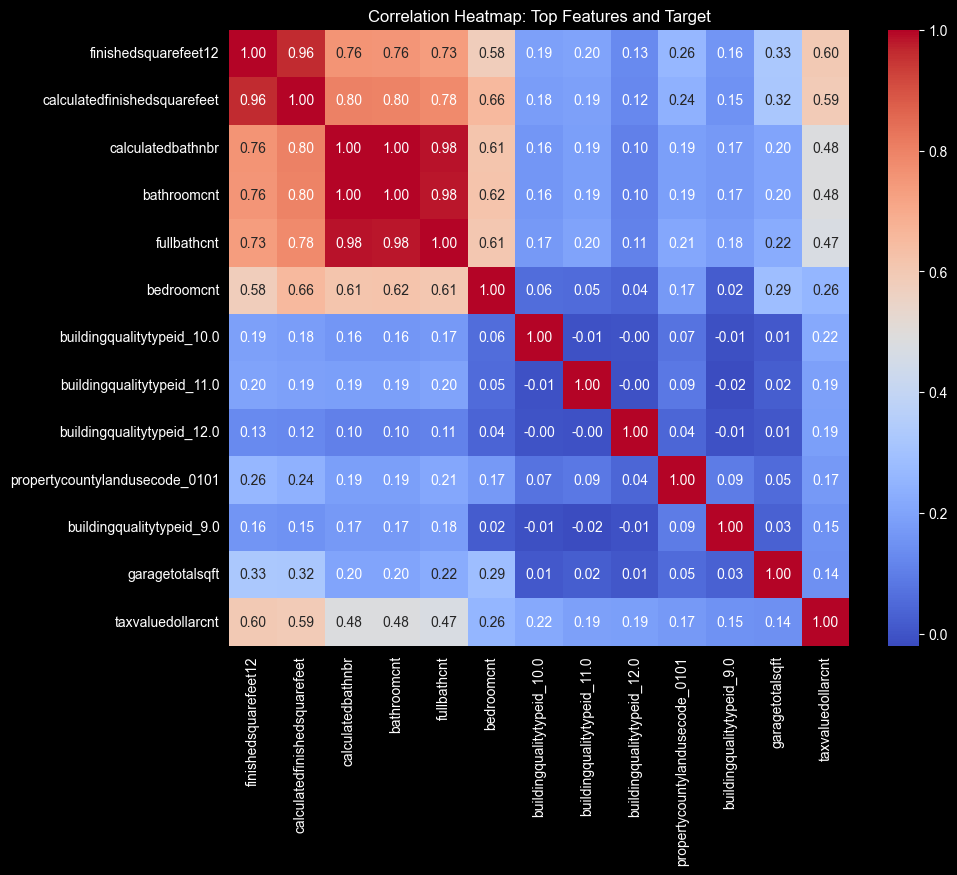

In [38]:
#  top 12 features most correlated with the target
top_corr_features = target_corr.abs().sort_values(ascending=False).head(12).index.tolist()

plt.figure(figsize=(10, 8))
sns.heatmap(
    df_part4[top_corr_features + [target]].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title("Correlation Heatmap: Top Features and Target")
plt.show()

In [39]:

#  F-statistics and p-values
f_scores, p_values = f_regression(X, y)

f_results = pd.DataFrame({
    'feature': X.columns,
    'f_statistic': f_scores,
    'p_value': p_values
}).sort_values(by='f_statistic', ascending=False)

print("Top features by F-statistic:")
print(f_results.head(20))

Top features by F-statistic:
                           feature   f_statistic        p_value
5             finishedsquarefeet12  42950.615802   0.000000e+00
4     calculatedfinishedsquarefeet  40638.669998   0.000000e+00
3                calculatedbathnbr  23362.566953   0.000000e+00
1                      bathroomcnt  23095.398346   0.000000e+00
6                      fullbathcnt  21891.972321   0.000000e+00
2                       bedroomcnt   5298.631935   0.000000e+00
27      buildingqualitytypeid_10.0   3762.123965   0.000000e+00
28      buildingqualitytypeid_11.0   2798.452778   0.000000e+00
29      buildingqualitytypeid_12.0   2700.888816   0.000000e+00
41  propertycountylandusecode_0101   2281.899561   0.000000e+00
26       buildingqualitytypeid_9.0   1776.138276   0.000000e+00
8                  garagetotalsqft   1622.872770   0.000000e+00
7                     garagecarcnt   1580.520038   0.000000e+00
32       heatingorsystemtypeid_2.0   1249.107370  2.093692e-271
34       he

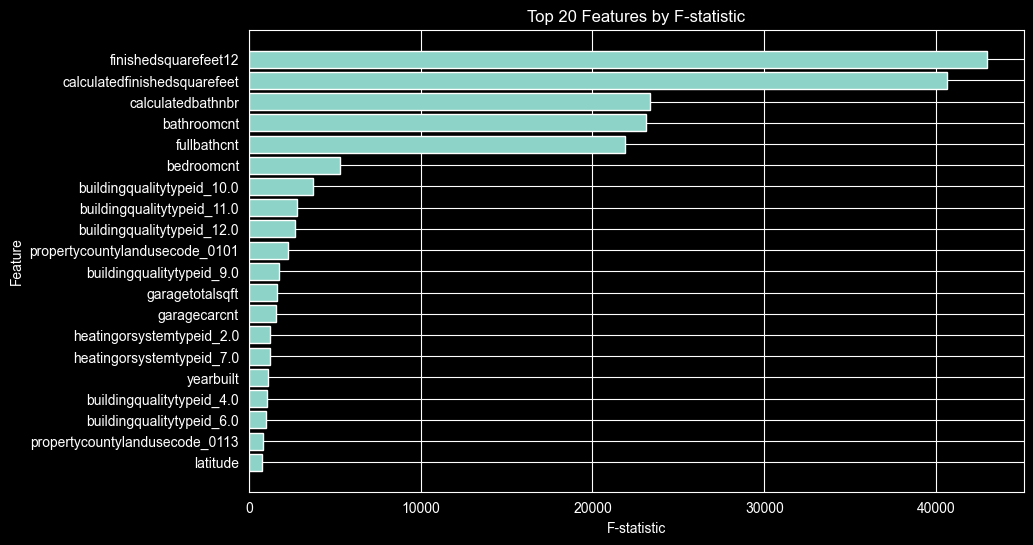

In [40]:
#  top 20 features by F-statistic
top_f = f_results.head(20)

plt.figure(figsize=(10, 6))
plt.barh(top_f['feature'][::-1], top_f['f_statistic'][::-1])
plt.title("Top 20 Features by F-statistic")
plt.xlabel("F-statistic")
plt.ylabel("Feature")
plt.show()

In [41]:
from sklearn.linear_model import LinearRegression


# top 15 features from F-statistics for sequential selection
top_features_for_sfs = f_results.head(15)['feature'].tolist()
X_sfs = X[top_features_for_sfs]

lr = LinearRegression()

forward_sfs = SequentialFeatureSelector(
    lr,
    n_features_to_select=8,
    direction='forward',
    scoring='neg_mean_squared_error',
    cv=3,
    n_jobs=-1
)

forward_sfs.fit(X_sfs, y)

forward_selected_features = X_sfs.columns[forward_sfs.get_support()].tolist()

print("Forward-selected features:")
print(forward_selected_features)

Forward-selected features:
['finishedsquarefeet12', 'calculatedfinishedsquarefeet', 'bathroomcnt', 'bedroomcnt', 'buildingqualitytypeid_10.0', 'buildingqualitytypeid_11.0', 'buildingqualitytypeid_12.0', 'buildingqualitytypeid_9.0']


In [42]:
backward_sfs = SequentialFeatureSelector(
    lr,
    n_features_to_select=8,
    direction='backward',
    scoring='neg_mean_squared_error',
    cv=3,
    n_jobs=-1
)

backward_sfs.fit(X_sfs, y)

backward_selected_features = X_sfs.columns[backward_sfs.get_support()].tolist()

print("Backward-selected features:")
print(backward_selected_features)

Backward-selected features:
['finishedsquarefeet12', 'calculatedfinishedsquarefeet', 'bathroomcnt', 'bedroomcnt', 'buildingqualitytypeid_10.0', 'buildingqualitytypeid_11.0', 'buildingqualitytypeid_12.0', 'heatingorsystemtypeid_7.0']


#### **4.A Discussion:**  Describe in a paragraph what you see in the feature relationships and correlations.

Pay particular attention to especially interesting and/or strongly correlated feature relationships. 
 How do the different methods for seeing relationships compare? Do they agree or disagree?



The feature relationship analysis shows that the strongest predictors of taxvaluedollarcnt are still related to home size and bathrooms. In particular, finishedsquarefeet12 and calculatedfinishedsquarefeet have the strongest positive correlations with the target, while calculatedbathnbr, bathroomcnt, and fullbathcnt also show moderately strong positive relationships. One especially notable pattern is that several predictors are also very strongly correlated with each other, especially the two square-footage variables and the bathroom-related features, which suggests multicollinearity and possible redundancy. The forward and backward feature selection methods also overlap heavily, since both selected finishedsquarefeet12, calculatedfinishedsquarefeet, bathroomcnt, bedroomcnt, and several buildingqualitytypeid variables. However, they are not identical, since forward selection kept buildingqualitytypeid_9.0 while backward selection kept heatingorsystemtypeid_7.0, which suggests that some features may contain similar predictive information and can substitute for one another depending on the selection path.

### Part 4.B:  2-Dimensional Visualizations for Interesting Patterns  
   - Select three (3) pairs of features that exhibit meaningful relationships based on your previous analysis. 
   - Create 2D scatter plots or density plots to explore interactions between these features.  
   - Provide brief interpretations of any observed patterns or trends. 

In [43]:
#2D visualizations for interesting feature pairs

df_part4b = df_part3e.copy()

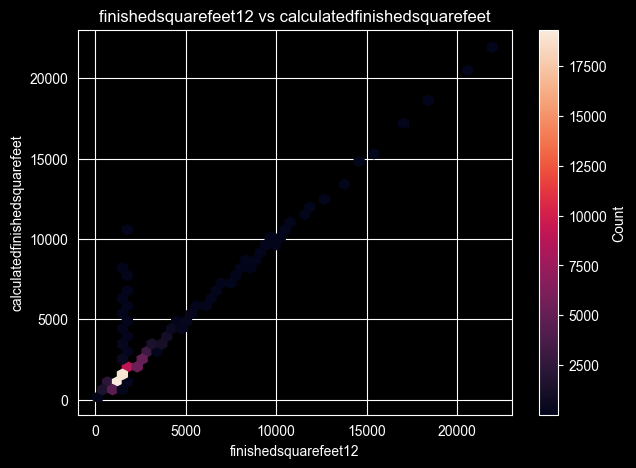

In [44]:
# finishesquarefeet12 vs calculatedfinishedsquarefeet were highly correlated.
plt.figure(figsize=(7,5))
plt.hexbin(
    df_part4b['finishedsquarefeet12'],
    df_part4b['calculatedfinishedsquarefeet'],
    gridsize=40,
    mincnt=1
)
plt.colorbar(label='Count')
plt.xlabel('finishedsquarefeet12')
plt.ylabel('calculatedfinishedsquarefeet')
plt.title('finishedsquarefeet12 vs calculatedfinishedsquarefeet')
plt.show()

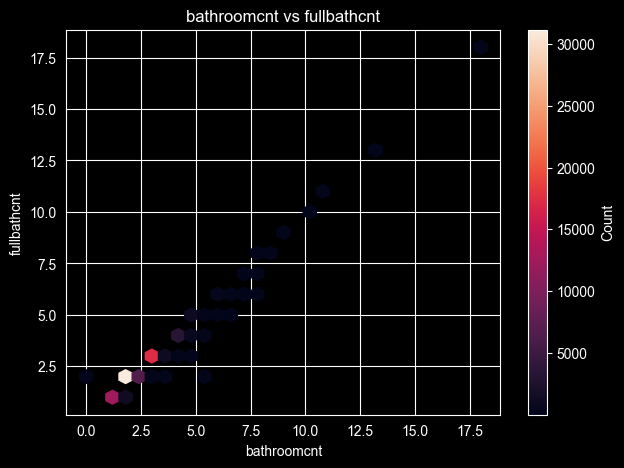

In [45]:
#bathroomcnt vs fullbathcnt were also very strongly correlated.
plt.figure(figsize=(7,5))
plt.hexbin(
    df_part4b['bathroomcnt'],
    df_part4b['fullbathcnt'],
    gridsize=30,
    mincnt=1
)
plt.colorbar(label='Count')
plt.xlabel('bathroomcnt')
plt.ylabel('fullbathcnt')
plt.title('bathroomcnt vs fullbathcnt')
plt.show()

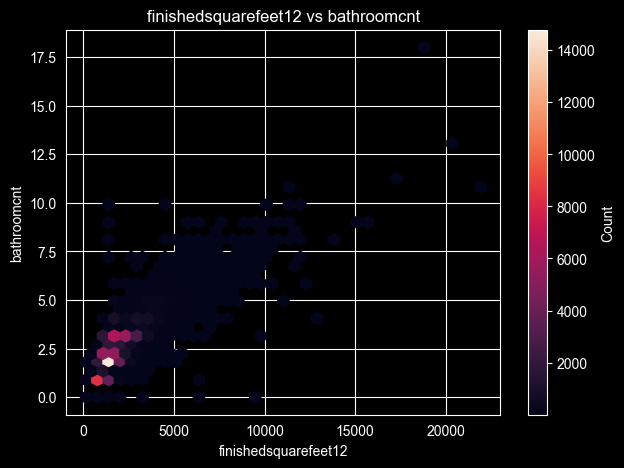

In [46]:
#larger homes often have more bathrooms
plt.figure(figsize=(7,5))
plt.hexbin(
    df_part4b['finishedsquarefeet12'],
    df_part4b['bathroomcnt'],
    gridsize=35,
    mincnt=1
)
plt.colorbar(label='Count')
plt.xlabel('finishedsquarefeet12')
plt.ylabel('bathroomcnt')
plt.title('finishedsquarefeet12 vs bathroomcnt')
plt.show()

#### **4.B Discussion:** Provide brief interpretations of any observed patterns or trends.
Answer: The plot of finishedsquarefeet12 versus calculatedfinishedsquarefeet shows an almost perfectly positive linear relationship, which suggests that these two variables are measuring nearly the same aspect of home size and may be somewhat redundant. The plot of bathroomcnt versus fullbathcnt also shows a very strong positive relationship, with most observations falling along a narrow diagonal pattern, which indicates that these two bathroom-related features contain highly overlapping information. The plot of finishedsquarefeet12 versus bathroomcnt shows a positive but more dispersed relationship, meaning that larger homes generally tend to have more bathrooms, although the pattern is not perfectly linear and includes several outliers. Overall, these plots reinforce the earlier correlation analysis by showing both strong multicollinearity among some predictors and a more realistic structural relationship between home size and bathroom count.

## Part 5:  Feature Engineering: Investigate various transformations to better expose the underlying data patterns to machine learning algorithms. [6 pts]

**Important Notes:**  
- This last part is a bit open ended, since there is a huge variety of feature engineering techniques, most of which won't be useful for your particular dataset. 
- Understand that you can't evaluate the final usefulness of these transformations
until you choose a model, and  models may respond differently to various transformations or obviate some transformations (e.g., ensemble methods already do feature selection). 
- Therefore, write your transformations as functions or otherwise be prepared
to choose later on which transformations may be necessary. 

**Investigate feature engineering, where appropriate:**

- Feature scaling: standardize or normalize features as necessary
- Decompose features (e.g., categorical into One-Hot feature sequence, date/time into two features data and time, etc.).
- Add promising transformations of features
    - Exponential $\exp(x_i)$ or logarithmic $\log(x_j)$
    - Polynomial features  ( $x_i^2$, $x_i - x_j$), products ($x_i*x_j$), or ratios ($x_i/x_j$)

**ToDo:**
- Pick at least three transformations to try.
- Try each one and evaluate its effect using correlations or F-scores or a feature selection algorithm.
- Answer the discussion question. 

In [47]:
df_part5 = df_part3e.copy()
target = 'taxvaluedollarcnt'

In [48]:
def add_engineered_features(df):
    df_out = df.copy()

    # 1. Log transformations for skewed size-related features
    if 'lotsizesquarefeet' in df_out.columns:
        df_out['log_lotsizesquarefeet'] = np.log1p(df_out['lotsizesquarefeet'])

    if 'finishedsquarefeet12' in df_out.columns:
        df_out['log_finishedsquarefeet12'] = np.log1p(df_out['finishedsquarefeet12'])

    if 'calculatedfinishedsquarefeet' in df_out.columns:
        df_out['log_calculatedfinishedsquarefeet'] = np.log1p(df_out['calculatedfinishedsquarefeet'])

    # ratio features
    if 'bathroomcnt' in df_out.columns and 'bedroomcnt' in df_out.columns:
        df_out['bath_bed_ratio'] = df_out['bathroomcnt'] / (df_out['bedroomcnt'] + 1)

    if 'finishedsquarefeet12' in df_out.columns and 'lotsizesquarefeet' in df_out.columns:
        df_out['living_lot_ratio'] = df_out['finishedsquarefeet12'] / (df_out['lotsizesquarefeet'] + 1)

    # age
    if 'yearbuilt' in df_out.columns:
        df_out['property_age'] = 2016 - df_out['yearbuilt']

    # 4. interaction features
    if 'finishedsquarefeet12' in df_out.columns:
        df_out['finishedsquarefeet12_sq'] = df_out['finishedsquarefeet12'] ** 2

    if 'finishedsquarefeet12' in df_out.columns and 'bathroomcnt' in df_out.columns:
        df_out['sqft_x_bathrooms'] = df_out['finishedsquarefeet12'] * df_out['bathroomcnt']

    return df_out

In [49]:
df_part5_eng = add_engineered_features(df_part5)
print("Original shape:", df_part5.shape)
print("Engineered shape:", df_part5_eng.shape)

Original shape: (76022, 119)
Engineered shape: (76022, 127)


In [50]:
engineered_cols = [
    'log_lotsizesquarefeet',
    'log_finishedsquarefeet12',
    'log_calculatedfinishedsquarefeet',
    'bath_bed_ratio',
    'living_lot_ratio',
    'property_age',
    'finishedsquarefeet12_sq',
    'sqft_x_bathrooms'
]

engineered_cols = [col for col in engineered_cols if col in df_part5_eng.columns]

engineered_corr = (
    df_part5_eng[engineered_cols + [target]]
    .corr(numeric_only=True)[target]
    .drop(target)
    .sort_values(key=np.abs, ascending=False)
)

print("Correlations of engineered features with taxvaluedollarcnt:")
print(engineered_corr)

Correlations of engineered features with taxvaluedollarcnt:
sqft_x_bathrooms                    0.667378
finishedsquarefeet12_sq             0.647367
log_finishedsquarefeet12            0.478830
log_calculatedfinishedsquarefeet    0.471682
bath_bed_ratio                      0.309830
living_lot_ratio                    0.172080
property_age                       -0.121547
log_lotsizesquarefeet               0.045647
Name: taxvaluedollarcnt, dtype: float64


In [51]:


X_eng = df_part5_eng[engineered_cols]
y_eng = df_part5_eng[target]

f_scores_eng, p_values_eng = f_regression(X_eng, y_eng)

eng_results = pd.DataFrame({
    'feature': engineered_cols,
    'correlation_with_target': [engineered_corr[col] for col in engineered_cols],
    'f_statistic': f_scores_eng,
    'p_value': p_values_eng
}).sort_values(by='f_statistic', ascending=False)

eng_results

,feature,correlation_with_target,f_statistic,p_value
7,sqft_x_bathrooms,0.667378,61050.249555,0.000000e+00
6,finishedsquarefeet12_sq,0.647367,54842.211893,0.000000e+00
1,log_finishedsquarefeet12,0.478830,22614.831762,0.000000e+00
2,log_calculatedfinishedsquarefeet,0.471682,21752.873639,0.000000e+00
3,bath_bed_ratio,0.309830,8072.404039,0.000000e+00
4,living_lot_ratio,0.172080,2319.764792,0.000000e+00
5,property_age,-0.121547,1139.933343,4.792112e-248
0,log_lotsizesquarefeet,0.045647,158.729560,2.331399e-36


Text(0, 0.5, 'Feature')

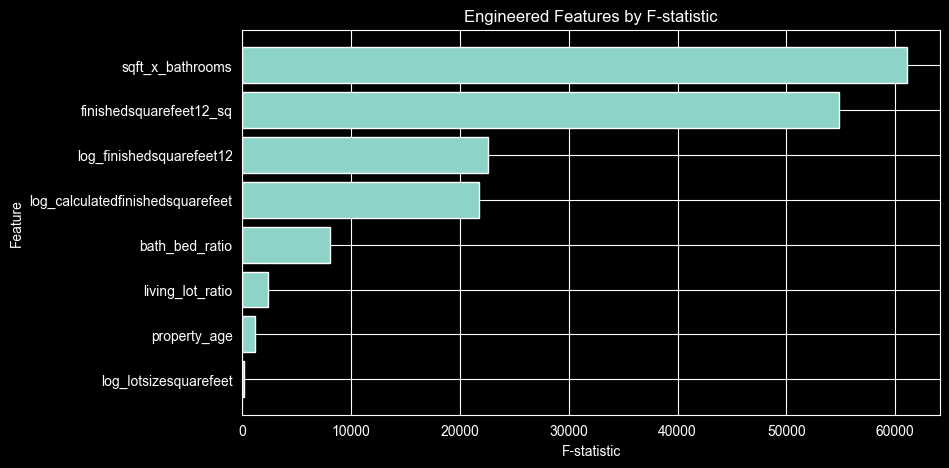

In [52]:
plt.figure(figsize=(9, 5))
plt.barh(eng_results['feature'][::-1], eng_results['f_statistic'][::-1])
plt.title('Engineered Features by F-statistic')
plt.xlabel('F-statistic')
plt.ylabel('Feature')


In [53]:
X_all = df_part5_eng.drop(columns=[target])
y_all = df_part5_eng[target]

f_scores_all, p_values_all = f_regression(X_all, y_all)

all_results = pd.DataFrame({
    'feature': X_all.columns,
    'f_statistic': f_scores_all,
    'p_value': p_values_all
}).sort_values(by='f_statistic', ascending=False)

print(" 20 features after adding engineered variables:")
print(all_results.head(20))

 20 features after adding engineered variables:
                              feature   f_statistic        p_value
125                  sqft_x_bathrooms  61050.249555   0.000000e+00
124           finishedsquarefeet12_sq  54842.211894   0.000000e+00
5                finishedsquarefeet12  42950.615802   0.000000e+00
4        calculatedfinishedsquarefeet  40638.669998   0.000000e+00
3                   calculatedbathnbr  23362.566953   0.000000e+00
1                         bathroomcnt  23095.398346   0.000000e+00
119          log_finishedsquarefeet12  22614.831762   0.000000e+00
6                         fullbathcnt  21891.972321   0.000000e+00
120  log_calculatedfinishedsquarefeet  21752.873639   0.000000e+00
121                    bath_bed_ratio   8072.404039   0.000000e+00
2                          bedroomcnt   5298.631935   0.000000e+00
27         buildingqualitytypeid_10.0   3762.123965   0.000000e+00
28         buildingqualitytypeid_11.0   2798.452778   0.000000e+00
29         bui

In [54]:


def scale_numeric_features(df, target='taxvaluedollarcnt'):
    df_out = df.copy()
    numeric_cols = df_out.select_dtypes(include=[np.number]).columns.tolist()
    numeric_cols = [col for col in numeric_cols if col != target]

    scaler = StandardScaler()
    df_out[numeric_cols] = scaler.fit_transform(df_out[numeric_cols])

    return df_out, numeric_cols

df_part5_scaled, scaled_cols = scale_numeric_features(df_part5_eng, target=target)
print("Scaled numeric columns:", len(scaled_cols))

Scaled numeric columns: 27


#### **5 Discussion:** Describe in a paragraph why you chose these transformations and what you observed.
Answer:
I investigated several feature engineering transformations to see whether they could expose stronger patterns than the original features alone. I tried log transformations on skewed size-related variables, ratio features such as bath_bed_ratio and living_lot_ratio, and nonlinear interaction features such as finishedsquarefeet12_sq and sqft_x_bathrooms. Among these, the strongest new features were sqft_x_bathrooms and finishedsquarefeet12_sq, which had correlations of about 0.67 and 0.65 with taxvaluedollarcnt and the highest F-statistics of all engineered features. This suggests that home value is influenced not just by size alone, but by nonlinear size effects and the interaction between square footage and bathroom count. The log-transformed square-footage variables were also useful, but they were weaker than the interaction and squared features. In contrast, log_lotsizesquarefeet had only a very weak relationship with the target, so that transformation does not appear especially helpful. These results suggest that feature engineering can improve the representation of the housing data, especially when focusing on nonlinear and interaction-based features tied to home size and structure.

## **Appendix 1: Features of the Zillow Dataset**  

0. **parcelid**: Unique identifier for the property parcel.  
1. **airconditioningtypeid**: Identifier for the type of air conditioning installed.  
2. **architecturalstyletypeid**: Identifier for the architectural style of the property.  
3. **basementsqft**: Square footage of the basement.  
4. **bathroomcnt**: Number of bathrooms.  
5. **bedroomcnt**: Number of bedrooms.  
6. **buildingclasstypeid**: Identifier for the building framing type (e.g., wood frame, steel frame).  
7. **buildingqualitytypeid**: Numeric value indicating the quality of the building (higher values often indicate better quality).  
8. **calculatedbathnbr**: Calculated number of bathrooms, including fractional bathrooms.  
9. **decktypeid**: Identifier for the type of deck.  
10. **finishedfloor1squarefeet**: Square footage of the finished area on the first floor.  
11. **calculatedfinishedsquarefeet**: Total finished living area square footage.  
12. **finishedsquarefeet12**: Finished living area square footage.  
13. **finishedsquarefeet13**: Perimeter living area square footage.  
14. **finishedsquarefeet15**: Total area.  
15. **finishedsquarefeet50**: Square footage of the finished area on the upper floors.  
16. **finishedsquarefeet6**: Base unfinished and finished area square footage.  
17. **fips**: Federal Information Processing Standards code, uniquely identifying counties and county equivalents.  
18. **fireplacecnt**: Number of fireplaces.  
19. **fullbathcnt**: Number of full bathrooms.  
20. **garagecarcnt**: Number of cars that can fit in the garage.  
21. **garagetotalsqft**: Total square footage of the garage.  
22. **hashottuborspa**: Indicates if the property has a hot tub or spa.  
23. **heatingorsystemtypeid**: Identifier for the type of heating system.  
24. **latitude**: Latitude coordinate of the property.  
25. **longitude**: Longitude coordinate of the property.  
26. **lotsizesquarefeet**: Lot size in square feet.  
27. **poolcnt**: Number of pools on the property.  
28. **poolsizesum**: Total square footage of all pools.  
29. **pooltypeid10**: Identifier for spa or hot tub.  
30. **pooltypeid2**: Identifier for pool with spa or hot tub.  
31. **pooltypeid7**: Identifier for pool without hot tub or spa.  
32. **propertycountylandusecode**: County land use code for the property.  
33. **propertylandusetypeid**: Identifier for the property land use type.  
34. **propertyzoningdesc**: Description of the property's zoning.  
35. **rawcensustractandblock**: Unprocessed census tract and block identifier.  
36. **regionidcity**: Identifier for the city.  
37. **regionidcounty**: Identifier for the county.  
38. **regionidneighborhood**: Identifier for the neighborhood.  
39. **regionidzip**: Identifier for the ZIP code.  
40. **roomcnt**: Total number of rooms.  
41. **storytypeid**: Identifier for the type of stories in the building (e.g., basement, attic).  
42. **threequarterbathnbr**: Number of 3/4 bathrooms (typically includes a shower but no tub).  
43. **typeconstructiontypeid**: Identifier for the type of construction (e.g., frame, masonry).  
44. **unitcnt**: Number of units in the building (e.g., for multi-family properties).  
45. **yardbuildingsqft17**: Square footage of the 17th yard building (e.g., shed).  
46. **yardbuildingsqft26**: Square footage of the 26th yard building.  
47. **yearbuilt**: Year the property was built.  
48. **numberofstories**: Number of stories in the building.  
49. **fireplaceflag**: Indicates if the property has a fireplace.  
50. **assessmentyear**: Year the property was assessed.  
51. **taxdelinquencyflag**: Indicates whether the property’s taxes are delinquent. Often “Y” if taxes are past due; otherwise null/empty.  
52. **taxdelinquencyyear**: The year in which the property’s taxes became delinquent.  
53. **censustractandblock**: A combined identifier for the property’s census tract and block group (part of the U.S. Census geographic hierarchy).  
54. **taxvaluedollarcnt**: Total assessed value of the property (land plus structure) in dollars.  


## Appendix 2: Summary of Basic Imputation Methods
Imputation depends on the data type and context. Below are common techniques for handling missing values.

---

### **1. Simple Imputation (Basic Methods)**
| Method | Best For | Code Example | Pros | Cons |
|--------|---------|--------------|------|------|
| **Drop Missing Values** | Few missing values (<5% of data) | `df.dropna()` | Quick and easy | Can remove valuable data |
| **Mean Imputation** | Normally distributed numerical data | `df.fillna(df.mean())` | Preserves mean; simple | Distorts variance, weak for skewed data |
| **Median Imputation** | Skewed numerical data | `df.fillna(df.median())` | Robust to outliers | May not capture patterns |
| **Mode Imputation** | Categorical features | `df.fillna(df.mode().iloc[0])` | Keeps most common category | Can introduce bias |
| **Constant Value (e.g., 0)** | Special cases (e.g., unknown numerical data) | `df.fillna(0)` | Simple and interpretable | Can mislead model |
| **"Unknown" Category Imputation** (**New Addition**) | Categorical features with missing values | `df.fillna('Unknown')` | Keeps all rows, prevents data loss | May introduce artificial category |

---

### **2. Statistical & Advanced Imputation**
| Method | Best For | Code Example | Pros | Cons |
|--------|---------|--------------|------|------|
| **Interpolation** | Time series, ordered data | `df.interpolate(method='linear')` | Preserves trends | May not work for non-continuous data |
| **K-Nearest Neighbors (KNN)** | Small datasets, patterns in features | `KNNImputer(n_neighbors=5).fit_transform(df)` | Uses similar observations | Computationally expensive |
| **Multivariate Imputation (MICE)** | Complex relationships between variables | `IterativeImputer().fit_transform(df)` | Captures relationships | Slower than mean/median |
| **Regression Imputation** | When missing values depend on other variables | Train regression model to predict missing values | More accurate than mean/median | Risk of overfitting |

---

### **When to Use "Unknown" Category for Categorical Imputation**
✅ **Good for:**
- Categorical features where missing values may indicate meaningful differences.  
- Customer data (e.g., missing survey responses → "No Response").  
- Product categories where missing could be a separate group.  

❌ **Avoid if:**
- The missing category does **not** have a meaningful interpretation.
- The model might learn spurious patterns from an artificial category.

---

### **Which Method to Choose?**
| Scenario | Best Method |
|----------|------------|
| **Few missing values (<5%)** | Drop NaNs (`df.dropna()`) |
| **Numerical & normal distribution** | Mean (`df.fillna(df.mean())`) |
| **Numerical & skewed distribution** | Median (`df.fillna(df.median())`) |
| **Categorical features** | Mode (`df.fillna(df.mode().iloc[0])`) |
| **Categorical with possible meaning in missingness** | "Unknown" Category (`df.fillna('Unknown')`) |
| **Small dataset with patterns** | KNN Imputer (`KNNImputer()`) |
| **Complex relationships between features** | MICE / Iterative Imputer |

